In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import geopandas as gpd
import celltypist
import decoupler as dc
from scipy.io import mmread
from sklearn.utils import sparsefuncs
import scipy.sparse as sp
import celltypist
from celltypist import models

In [ ]:
sample = "Pat13_W12"

um = '008'
print ("Reading in segmentation for sample " + sample)
data_directory = "../segmentation/" + sample + "/"
adata = anndata.read_h5ad(data_directory + sample + "_" + um + ".h5ad")
adata

In [4]:
sc.pp.filter_cells(adata, min_genes=50)
sc.pp.filter_genes(adata, min_cells=50)

#remove cells with high mitochondrial content
mito_genes = adata.var_names.str.startswith('MT-')
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata = adata[adata.obs['percent_mito'] < 0.05, :]

#remove mitochondrial genes
adata = adata[:, [gene for gene in adata.var_names if not gene.startswith('MT-')]]
adata

View of AnnData object with n_obs × n_vars = 212665 × 13224
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    obsm: 'spatial'

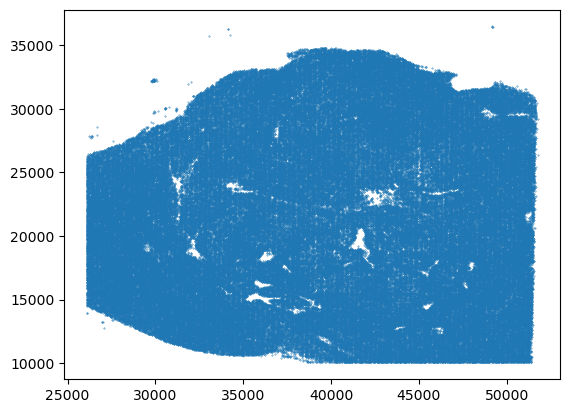

In [5]:
plt.scatter(adata.obsm["spatial"][:,0], adata.obsm["spatial"][:,1], s=0.1)

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
#sc.pp.scale(adata)

In [7]:
# PCA
sc.tl.pca(adata)
# Compute nearest neighbors
sc.pp.neighbors(adata)
# UMAP for visualization
sc.tl.umap(adata)

2025-03-21 11:33:40.507296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-21 11:33:40.529032: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-21 11:33:40.553224: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-21 11:33:40.560243: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-21 11:33:40.577960: I tensorflow/core/platform/cpu_feature_guar

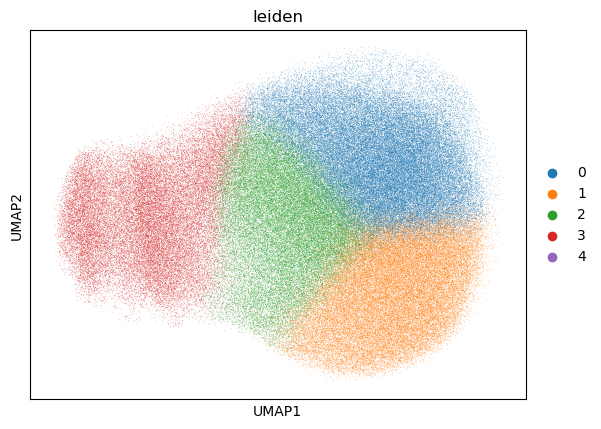

In [8]:
# Clustering
sc.tl.leiden(adata, resolution=0.8)  
# Visualize clusters
sc.pl.umap(adata, color=["leiden"])

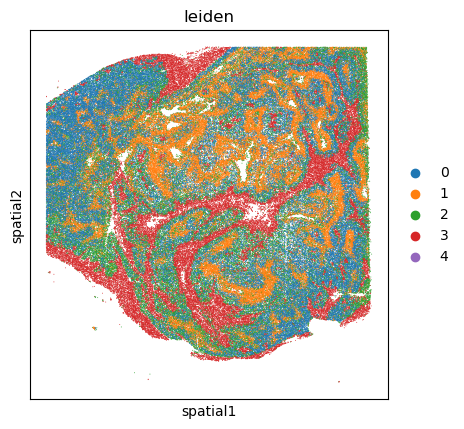

In [9]:
sc.pl.spatial(adata, color='leiden', spot_size=70, alpha_img=1)

In [10]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

In [11]:
adata.obs["leiden"].value_counts()

0    69717
1    53422
2    47882
3    41641
4        3
Name: leiden, dtype: int64

In [12]:
clusters = adata.obs['leiden'].unique()
de_results = {}
for cluster in clusters:
    cluster_results = pd.DataFrame({
        'gene': adata.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': adata.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': adata.uns['rank_genes_groups']['pvals'][cluster],
        'pvals_adj': adata.uns['rank_genes_groups']['pvals_adj'][cluster]
    })
    #only include positive logfoldchanges
    cluster_results = cluster_results[cluster_results['logfoldchanges'] > 0]
    de_results[cluster] = cluster_results

#print the top 20 genes for each cluster sorted by p-value
for cluster, results in de_results.items():
    print(f"Cluster {cluster}")
    print(results.head(50))
    print("\n")

Cluster 3
        gene  logfoldchanges          pvals      pvals_adj
0     TMSB4X        6.471766   0.000000e+00   0.000000e+00
1       IGKC        5.781788   0.000000e+00   0.000000e+00
2       CD74        3.045034   0.000000e+00   0.000000e+00
3      IGHG1        5.511227   0.000000e+00   0.000000e+00
4     TMSB10        1.457538   0.000000e+00   0.000000e+00
5     COL3A1        3.657543   0.000000e+00   0.000000e+00
6       ACTB        1.711463   0.000000e+00   0.000000e+00
7        FTL        2.036927   0.000000e+00   0.000000e+00
8       PSAP        1.912868   0.000000e+00   0.000000e+00
9       CTSB        1.470053   0.000000e+00   0.000000e+00
10       LYZ        4.115553   0.000000e+00   0.000000e+00
11    COL1A1        3.298786   0.000000e+00   0.000000e+00
12      TRAC        3.837408   0.000000e+00   0.000000e+00
13      CTSZ        1.914828   0.000000e+00   0.000000e+00
14      C1QC        3.205000   0.000000e+00   0.000000e+00
15     TRBC2        3.758162   0.000000e+00   

In [13]:
# Pat03_W4
cell_type_names = {
    "0": "Melanocytes", 
    "1": "Fibroblasts - Stroma cells",
    "2": "Melanocytes",
    "3": "B cells",
    "4": "nan",
}

adata.obs["cell_type"] = adata.obs["leiden"].astype(str).map(cell_type_names)
adata.obs["cell_annotation"] = np.where(adata.obs["cell_type"] == "Melanocytes", "Tumor", "TME")
adata = adata[adata.obs["cell_type"] != "nan"]

... storing 'cell_type' as categorical
... storing 'cell_annotation' as categorical


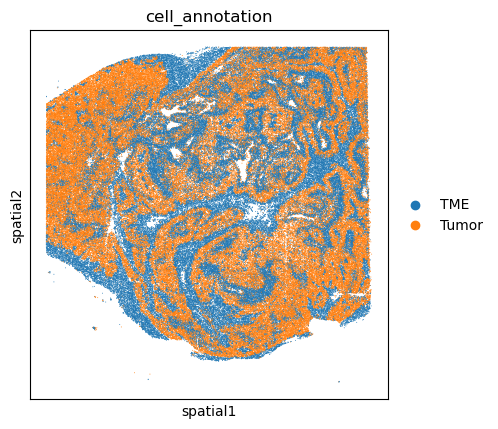

In [14]:
sc.pl.spatial(adata, color='cell_annotation', spot_size=70, alpha_img=1)

In [15]:
adata.write(data_directory + sample + "_" + um + "_processed.h5ad")